# ***TRATAMIENTO DE LAS PROBLEMÁTICAS***

In [155]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, f1_score 
from imblearn.over_sampling import SMOTE
import seaborn as sns
import shap
import numpy as np
import matplotlib.patches as mpatches
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lime.lime_tabular import LimeTabularExplainer
from matplotlib.colors import ListedColormap
import random

In [7]:
df = pd.read_csv('../data/diabetes_preprocesado.csv', sep=",", quotechar='"')

cols_to_drop = ['encounter_id', 'patient_nbr']
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

y = df["readmitted"]
X = df.drop(columns=["readmitted"])

X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=SEED,
        stratify=y
    )

## 1- Datos desbalanceados

El dataset presenta una distribución desigual en la variable objetivo **"readmitted"**, lo que convierte el desbalanceo de clases en una problemática central del proyecto. En concreto, los casos de reingreso temprano aparecen en menor proporción que el resto, pese a ser precisamente los más importantes desde el punto de vista clínico. Esto puede hacer que el modelo aprenda patrones que beneficien a las clases mayoritarias y reduzca su capacidad para detectar pacientes que realmente podrían necesitar un mayor seguimiento. En este caso, el problema no es solo técnico, ya que ignorar a la clase minoritaria puede implicar no identificar a pacientes con riesgo elevado de volver a ingresar, lo que afectaría tanto a su salud como a la planificación de recursos del hospital.

Antes de SMOTE:
readmitted
0    41870
1    27719
2     8853
Name: count, dtype: int64

Después de SMOTE:
readmitted
0    41870
1    41870
2    41870
Name: count, dtype: int64


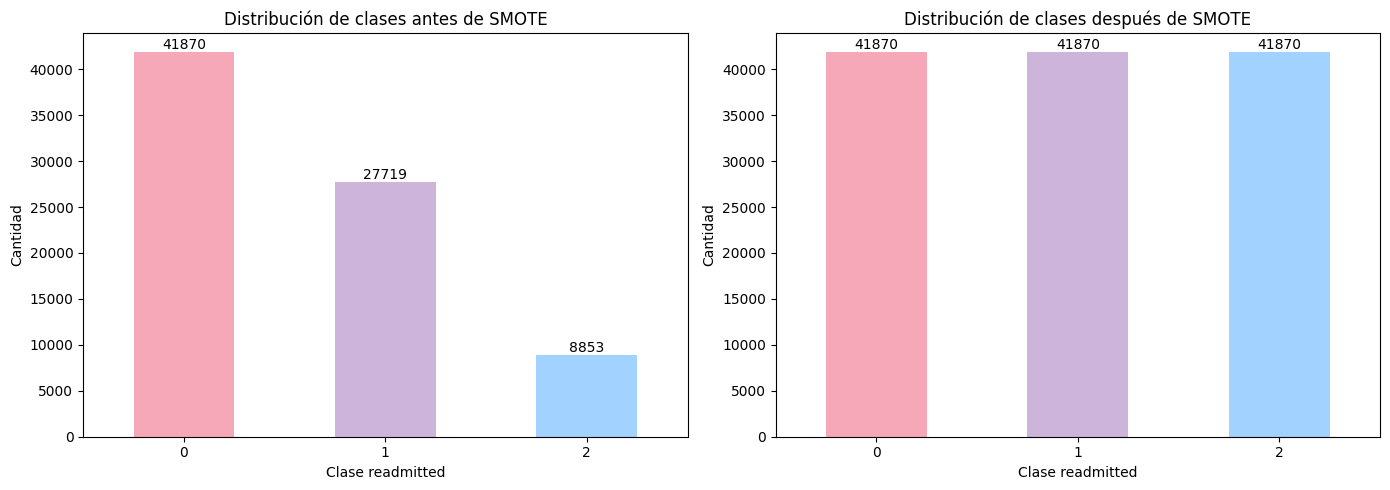

In [158]:
# Distribución antes de SMOTE
y_train_counts = pd.Series(y_train).value_counts()

print("Antes de SMOTE:")
print(y_train_counts)

# Aplicar SMOTE solo al entrenamiento
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)


# Distribución después de SMOTE
y_train_smote_counts = pd.Series(y_train_smote).value_counts()

print("\nDespués de SMOTE:")
print(y_train_smote_counts)

# Gráfica comparativa
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#F7A8B8', '#CDB4DB', '#A2D2FF']  # rosa, lila, azul pastel

# Antes
y_train_counts.plot(
    kind='bar',
    ax=axes[0],
    color=colors
)

axes[0].set_title("Distribución de clases antes de SMOTE")
axes[0].set_xlabel("Clase readmitted")
axes[0].set_ylabel("Cantidad")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

for p in axes[0].patches:
    axes[0].annotate(
        int(p.get_height()),
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center',
        va='bottom'
    )

# Después
y_train_smote_counts.plot(
    kind='bar',
    ax=axes[1],
    color=colors
)

axes[1].set_title("Distribución de clases después de SMOTE")
axes[1].set_xlabel("Clase readmitted")
axes[1].set_ylabel("Cantidad")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

for p in axes[1].patches:
    axes[1].annotate(
        int(p.get_height()),
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.savefig("../visualizacion_problematicas/smote_distribucion_clases.png", dpi=300, bbox_inches="tight")
plt.show()

Antes de aplicar ninguna técnica de balanceo, la distribución de clases en el conjunto de entrenamiento era muy desigual. Como se observa en la imagen, la clase mayoritaria contiene 41.870 instancias, mientras que las otras clases tienen 27.719 y 8.853 instancias, respectivamente. Esto significa que el modelo dispone de muchos más ejemplos de unas clases que de otras. Esta situación es habitual en problemas clínicos reales, ya que los eventos de mayor interés, como un reingreso temprano, suelen producirse con menor frecuencia.

Como se ha comentado, este desbalanceo es importante porque puede afectar directamente al comportamiento del modelo. Si se entrena un clasificador sobre estos datos, el modelo puede aprender a favorecer las clases mayoritarias, ya que esto le permite obtener buenos resultados sin identificar correctamente los casos menos frecuentes. Como se ha visto durante las fases anteriores de entrenamiento de modelos, una métrica como accuracy puede resultar engañosa, porque un modelo puede alcanzar una precisión aparentemente alta simplemente clasificando correctamente la clase mayoritaria. Sin embargo, al analizar métricas más informativas como el F1-score, se veía que el rendimiento era peor y que el modelo no estaba aprendiendo de forma equilibrada todas las categorías, sino que el desbalanceo estaba afectando a su capacidad para detectar correctamente los casos minoritarios.

En el contexto del problema esto es crítico, ya que un falso negativo, es decir, clasificar como bajo riesgo a un paciente que finalmente será readmitido en menos de 30 días, puede provocar que no reciba seguimiento adicional cuando realmente sí lo necesitaba. Esto puede aumentar el riesgo de complicaciones para el paciente y generar nuevos costes hospitalarios. 

Para tratar el desbalanceo de clases se ha utilizado la técnica SMOTE, que genera ejemplos sintéticos de las clases minoritarias a partir de muestras reales cercanas para equilibrar la distribución de clases. Esto se ha aplicado sobre el conjunto de entrenamiento para evitar data leakage. Si se aplicara antes de separar entrenamiento y test, las muestras sintéticas podrían generarse usando información de datos que después quedarían en el test. Esto haría que el modelo fuese evaluado con datos indirectamente parecidos a los que ya ha visto durante el entrenamiento, dando resultados demasiado optimistas.

Como resultado, tras aplicar SMOTE, las tres clases de quedan equilibradas con 41.870 instancias cada una en el conjunto de entrenamiento. Este resultado se observa claramente en la gráfica comparativa. Antes del tratamiento, la distribución estaba dominada por la clase 0, mientras que la clase 2 tenía una presencia mucho menor. Después de aplicar SMOTE, las tres barras tienen la misma altura, lo que confirma que el conjunto de entrenamiento ha quedado balanceado. De esta forma, durante el aprendizaje, el modelo no se ve tan condicionado por la frecuencia original de las clases.

## 2- Sesgo y Fairness

Para esta segunda problematica se ha decidido centrar el análisis de **Sesgo y Fairness** en las variables de raza, género y edad debido a que son datos sensibles, tanto desde una perspectiva legal como ética en el ámbito sanitario. A diferencia de las variables clínicas, como los niveles de glucosa o el tipo de medicación, que poseen una relación biológica con la posibilidad de readmisión, los atributos sociodemográficos no deberían determinar por sí mismos el resultado de la atención médica. El objetivo de este análisis no es encontrar correlaciones estadístivas generales en todo el dataset, sino identificar sesgos injustos o históricos que el modelo podría heredar y amplificar, asegurando así que el sistema de inteligencia artificial sea equitativo y no discrimine a grupos vulnerables al realizar predicciones que afectan a la salud de las personas.

De esta forma, se analiza la distribución de la variable objetivo (*readmitted*) a través de estas variables sensibles (race, gender, age). Si un grupo tiene una tasa de readmisión históricamente mucho más alta o baja, el modelo "heredará" este sesgo.

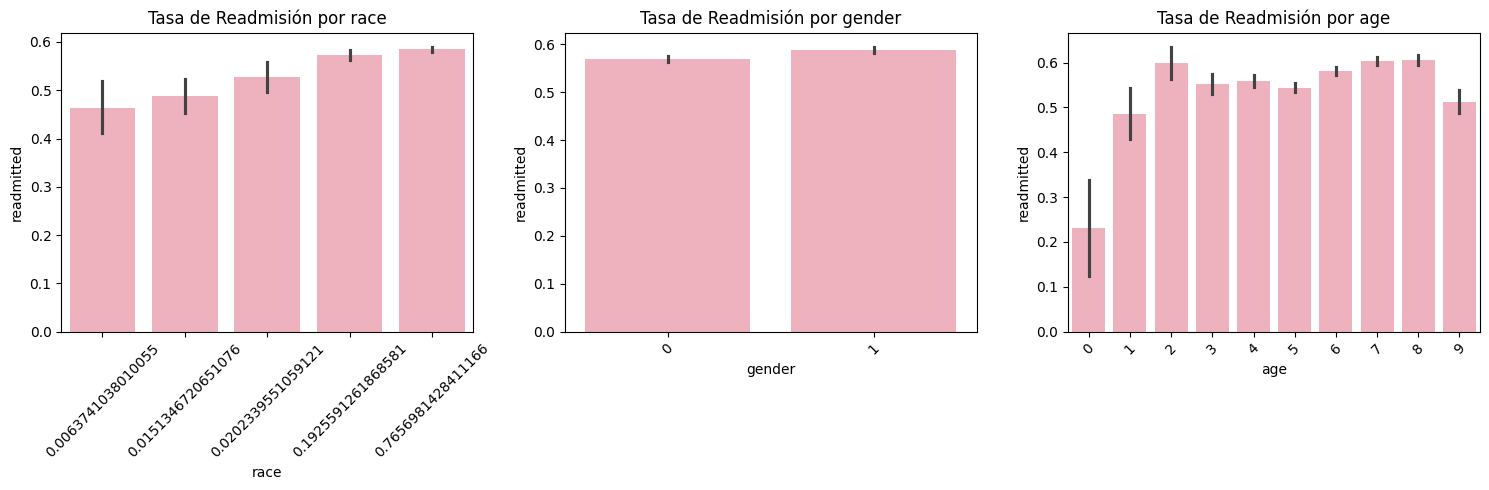

In [159]:
atributos_sensibles = ['race', 'gender', 'age']

plt.figure(figsize=(15, 5))

for i, col in enumerate(atributos_sensibles):
    plt.subplot(1, 3, i+1)
    sns.barplot(x=col, y='readmitted', data=df, color='#F7A8B8')
    plt.title(f'Tasa de Readmisión por {col}')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [160]:
def calcular_impacto_dispar(df, columna_sensible):
    tasas = df.groupby(columna_sensible)['readmitted'].mean()
    
    valor_privilegiado = tasas.idxmin()
    valor_no_privilegiado = tasas.idxmax()
    
    prob_priv = tasas.min()
    prob_no_priv = tasas.max()
    
    if prob_priv == 0:
        return 0, valor_privilegiado, valor_no_privilegiado
        
    impacto_dispar = prob_no_priv / prob_priv
    return impacto_dispar, valor_privilegiado, valor_no_privilegiado

variables_sensibles = ['gender', 'race', 'age']

print("--- ANÁLISIS DE IMPACTO DISPAR ---")
for var in variables_sensibles:
    id_val, priv, no_priv = calcular_impacto_dispar(df, var)
    
    print(f"\nVariable: {var}")
    print(f"  - Grupo con menor riesgo (Privilegiado): {priv}")
    print(f"  - Grupo con mayor riesgo (No Privilegiado): {no_priv}")
    print(f"  - Ratio de Impacto Dispar: {id_val:.4f}")
    
    # Interpretación de la Regla del 80% (o 1.25 en este caso por ser ratio de riesgo)
    if id_val > 1.25:
        print(f"  Existe un sesgo significativo. El grupo {no_priv} tiene un {((id_val-1)*100):.1f}% más de riesgo de readmisión que el grupo {priv}.")
    else:
        print(f" El sesgo parece estar dentro de los límites aceptables (inferior al 25% de diferencia).")

--- ANÁLISIS DE IMPACTO DISPAR ---

Variable: gender
  - Grupo con menor riesgo (Privilegiado): 0
  - Grupo con mayor riesgo (No Privilegiado): 1
  - Ratio de Impacto Dispar: 1.0339
 El sesgo parece estar dentro de los límites aceptables (inferior al 25% de diferencia).

Variable: race
  - Grupo con menor riesgo (Privilegiado): 0.0063741038010055
  - Grupo con mayor riesgo (No Privilegiado): 0.7656981428411166
  - Ratio de Impacto Dispar: 1.2645
  Existe un sesgo significativo. El grupo 0.7656981428411166 tiene un 26.4% más de riesgo de readmisión que el grupo 0.0063741038010055.

Variable: age
  - Grupo con menor riesgo (Privilegiado): 0
  - Grupo con mayor riesgo (No Privilegiado): 8
  - Ratio de Impacto Dispar: 2.6230
  Existe un sesgo significativo. El grupo 8 tiene un 162.3% más de riesgo de readmisión que el grupo 0.


En primer lugar, la variable **`gender`** presenta una situación de equidad casi ideal. Con un ratio de impacto dispar de **1.0339**, la diferencia de riesgo entre hombres y mujeres (grupos 0 y 1) es de apenas un **3.4%**. Este valor cae muy por debajo del umbral crítico del 25%, lo que indica que, para este dataset, el género no es un factor que introduzca una discriminación significativa de forma aislada. Por tanto, no requiere de medidas de mitigación.

Por el contrario, la variable **`race`** (raza) sí muestra un sesgo que supera los límites éticos aceptables. El grupo identificado con el valor `0.7656` presenta un **26.4% más de riesgo** de ser readmitido que el grupo de referencia. Este ratio de **1.2645** sobrepasa la "regla del 80%" (su inverso de 1.25), lo que sugiere que el modelo podría aprender a penalizar a ciertos grupos étnicos. Gestionar este sesgo es prioritario para evitar que el sistema presente desigualdades históricas en el acceso o la calidad de la atención médica.

Finalmente, la variable **`age`** (edad) presenta el caso más crítico y complejo, con un ratio de impacto dispar de **2.6230**. Esto significa que los pacientes del grupo de mayor edad (grupo 8) tienen un **162.3% más de riesgo** de readmisión que los del grupo más joven. Aunque en medicina la edad es un factor de riesgo clínico legítimo, una diferencia tan abismal indica que el modelo podría volverse dependiente de esta variable, ignorando otros indicadores médicos importantes. Trataremos esta variable para asegurar que el modelo sea robusto y no diagnostique "por edad", sino por la condición clínica real del paciente.

In [161]:
def calcular_pesos_fairness(df, columna_sensible, target):
    # Calculamos las probabilidades globales
    n = len(df)
    n_readmitted = df[target].sum()
    n_not_readmitted = n - n_readmitted
    
    weights = pd.Series(1.0, index=df.index)
    
    for grupo in df[columna_sensible].unique():
        # Subconjunto del grupo
        mask_grupo = (df[columna_sensible] == grupo)
        n_g = mask_grupo.sum()
        
        # Subconjunto del grupo y su resultado
        for label in [0, 1]:
            mask_label = (df[target] == label)
            n_gl = (mask_grupo & mask_label).sum()
            
            if n_gl > 0:
                # Fórmula de Re-weighting: (P(L) * P(G)) / P(G & L)
                # Proporción esperada si fueran independientes / Proporción observada
                proporcion_esperada = ( (n_readmitted if label==1 else n_not_readmitted) / n ) * (n_g / n)
                proporcion_real = n_gl / n
                
                weights.loc[mask_grupo & mask_label] = proporcion_esperada / proporcion_real
                
    return weights

# Aplicamos el cálculo para las dos variables problemáticas
weights_race = calcular_pesos_fairness(df, 'race', 'readmitted')
weights_age = calcular_pesos_fairness(df, 'age', 'readmitted')

# Combinamos los pesos
df['sample_weight'] = (weights_race + weights_age) / 2

print("Pesos generados correctamente. Valores min:", df['sample_weight'].min(), "max:", df['sample_weight'].max())

Pesos generados correctamente. Valores min: 0.5962502520025983 max: 2.283238449026199


Para gestionar esta problemática, hemos implementado una estrategia de mitigación que actúa directamente sobre la importancia que el modelo otorga a cada registro. Esta solución se basa en la creación de una nueva columna denominada **`sample_weight`**. Esta variable no es una característica clínica que el modelo deba usar para predecir, sino una herramienta de ajuste ético. Se genera mediante el cálculo de la probabilidad esperada de readmisión frente a la observada para cada grupo sensible. Al asignar un peso mayor a los casos que contradicen el sesgo histórico (por ejemplo, pacientes jóvenes readmitidos o pacientes de grupos raciales específicos no readmitidos), logramos "equilibrar la balanza" sin necesidad de eliminar datos valiosos, permitiendo que el algoritmo aprenda patrones médicos reales.

A la hora de preparar los datos para el entrenamiento, es fundamental que esta columna de pesos se trate de forma sincronizada con el resto del dataset. Al utilizar la función `train_test_split`, debemos incluir `sample_weight` como un tercer elemento de división junto a las características (`X`) y la variable objetivo (`y`). Esto garantiza que cada registro en el conjunto de entrenamiento mantenga asociado su peso correspondiente (`w_train`), preservando la integridad de la corrección del sesgo durante la fase de aprendizaje.

Finalmente, la aplicación práctica de esta técnica se realiza en el momento del entrenamiento. Al invocar el método `.fit()` de un modelo, se debe pasar el parámetro `sample_weight=w_train`. Con esto, el optimizador del modelo dará más importancia a los errores cometidos en ejemplos clave para la equidad, resultando en un sistema que no solo es preciso, sino que cumple con los estándares éticos y legales de imparcialidad requeridos.

## 3- Explicabilidad (XAI)

En este apartado abordamos la problemática de la **explicabilidad** (*Explainable AI, XAI*). Esta problemática es especialmente relevante en este contexto por dos motivos:

- **Ético y legal**: el modelo toma decisiones que afectan directamente a pacientes. El personal médico necesita entender *por qué* el modelo predice un alto riesgo de readmisión para poder actuar en consecuencia. 
- **Clínico**: las predicciones solo son útiles si se apoyan en variables médicamente razonables.

Se aplicarán dos técnicas complementarias:
1. **SHAP** (*SHapley Additive exPlanations*): explicaciones globales y locales basadas en teoría de juegos cooperativos.
2. **LIME** (*Local Interpretable Model-agnostic Explanations*): explicaciones locales mediante un modelo lineal aproximado en el entorno de cada instancia.

El modelo base utilizado es **XGBoost**, que es el modelo con mejor rendimiento sin tratar estas problematicas.

In [162]:
feature_names = list(X.columns)

print(f'Dataset: {X.shape[0]} instancias, {X.shape[1]} features')
print(f'\nDistribución de clases:')
print(y.value_counts().rename({0: 'No readmitido', 1: '>30 días', 2: '<30 días'}))

Dataset: 98053 instancias, 43 features

Distribución de clases:
readmitted
No readmitido    52338
>30 días         34649
<30 días         11066
Name: count, dtype: int64


In [163]:
print(f'Entrenamiento: {X_train_smote.shape[0]} instancias')
print(f'Test:          {X_test.shape[0]} instancias')

Entrenamiento: 125610 instancias
Test:          19611 instancias


### 3.1 Entrenamiento del modelo (XGBoost)

Entrenamos un clasificador **XGBoost** sobre los datos balanceados con SMOTE
(`X_train_smote`, `y_train_smote`) obtenidos en la sección 1, para mantener
coherencia con el pipeline general del proyecto. El conjunto de test (`X_test`,
`y_test`) permanece sin modificar, tal como se hizo en la evaluación del
desbalanceo, para que las métricas reflejen la distribución real.

In [164]:
# El modelo para XAI se entrena sobre los datos ya balanceados con SMOTE
# (X_train_smote, y_train_smote definidos en la sección 1 del notebook)
# Esto es coherente con el pipeline general del proyecto.

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    random_state=SEED,
    n_jobs=-1
)

xgb_model.fit(X_train_smote, y_train_smote)

y_pred = xgb_model.predict(X_test)
print('Rendimiento del modelo XGBoost entrenado con SMOTE (conjunto de test):')
print(classification_report(
    y_test, y_pred,
    target_names=['No readmitido (0)', '>30 días (1)', '<30 días (2)']
))
print(f'F1-macro: {f1_score(y_test, y_pred, average="macro"):.4f}')

Rendimiento del modelo XGBoost entrenado con SMOTE (conjunto de test):
                   precision    recall  f1-score   support

No readmitido (0)       0.62      0.81      0.70     10468
     >30 días (1)       0.50      0.42      0.46      6930
     <30 días (2)       0.40      0.05      0.09      2213

         accuracy                           0.58     19611
        macro avg       0.51      0.43      0.42     19611
     weighted avg       0.56      0.58      0.55     19611

F1-macro: 0.4171


### 3.2 Explicabilidad global con SHAP

SHAP asigna a cada feature una contribución (*Shapley value*) basada en su impacto marginal promedio a lo largo de todas las posibles combinaciones de features. Para modelos de árbol como XGBoost, `TreeExplainer` calcula los SHAP values de forma exacta y eficiente.

Dado que el problema es **multiclase** (3 clases), SHAP genera un valor por clase y feature. Analizaremos principalmente la clase de interés clínico: **readmisión temprana (<30 días, clase 2)**.

In [165]:
explainer = shap.TreeExplainer(xgb_model)

# Calculamos SHAP values sobre el conjunto de test completo
shap_values = explainer.shap_values(X_test)

print(f'Tipo de shap_values: {type(shap_values)}')
if isinstance(shap_values, list):
    print(f'Número de clases: {len(shap_values)}')
    print(f'Shape por clase: {shap_values[0].shape}')
else:
    print(f'Shape: {shap_values.shape}')

Tipo de shap_values: <class 'list'>
Número de clases: 3
Shape por clase: (19611, 43)


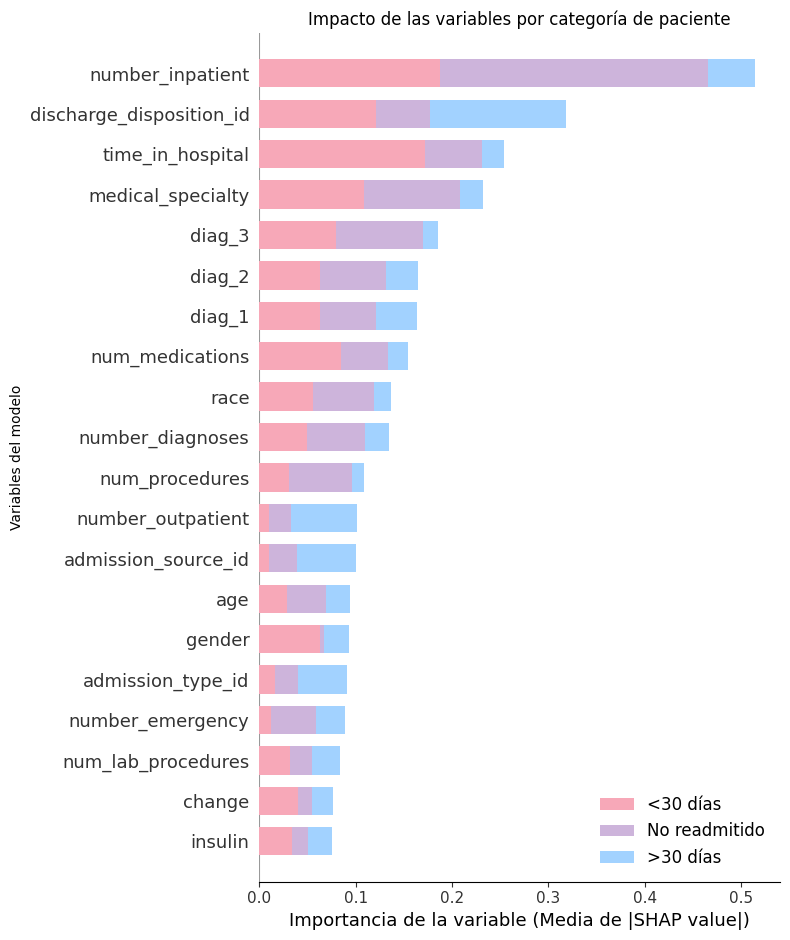

In [166]:
mapa = ListedColormap(colors) # Usamos el mapa de colores para evitar el TypeError

plt.figure(figsize=(10, 6))

shap.summary_plot(
    shap_values, 
    X_test, 
    plot_type="bar",
    color=mapa,  
    class_names=['No readmitido', '>30 días', '<30 días'],
    show=False      # Permitimos modificaciones posteriores
)

plt.xlabel("Importancia de la variable (Media de |SHAP value|)") 
plt.ylabel("Variables del modelo")
plt.title("Impacto de las variables por categoría de paciente")

plt.tight_layout()
plt.savefig("../visualizacion_problematicas/shap_bar.png")
plt.show()

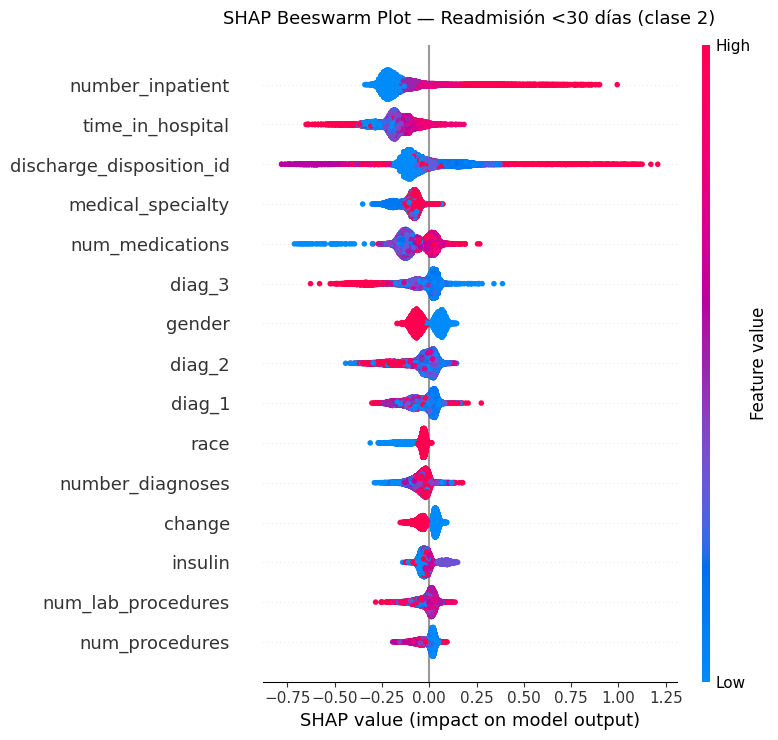

In [167]:
# --- BEESWARM PLOT (Summary Plot): importancia global + dirección del efecto ---
# Mostramos las top 15 features más importantes para predecir readmisión <30 días (clase 2)

# Índice de la clase de interés clínico: readmisión temprana
CLASS_IDX = 2
CLASS_NAME = 'Readmisión <30 días (clase 2)'

if isinstance(shap_values, list):
    sv_class = shap_values[CLASS_IDX]
else:
    sv_class = shap_values[:, :, CLASS_IDX]

plt.figure(figsize=(10, 8))
shap.summary_plot(
    sv_class,
    X_test,
    feature_names=feature_names,
    max_display=15,
    show=False,
    plot_type='dot'   # beeswarm
)
plt.title(f'SHAP Beeswarm Plot — {CLASS_NAME}', fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('../visualizacion_problematicas/shap_beeswarm_clase2.png', dpi=150, bbox_inches='tight')
plt.show()

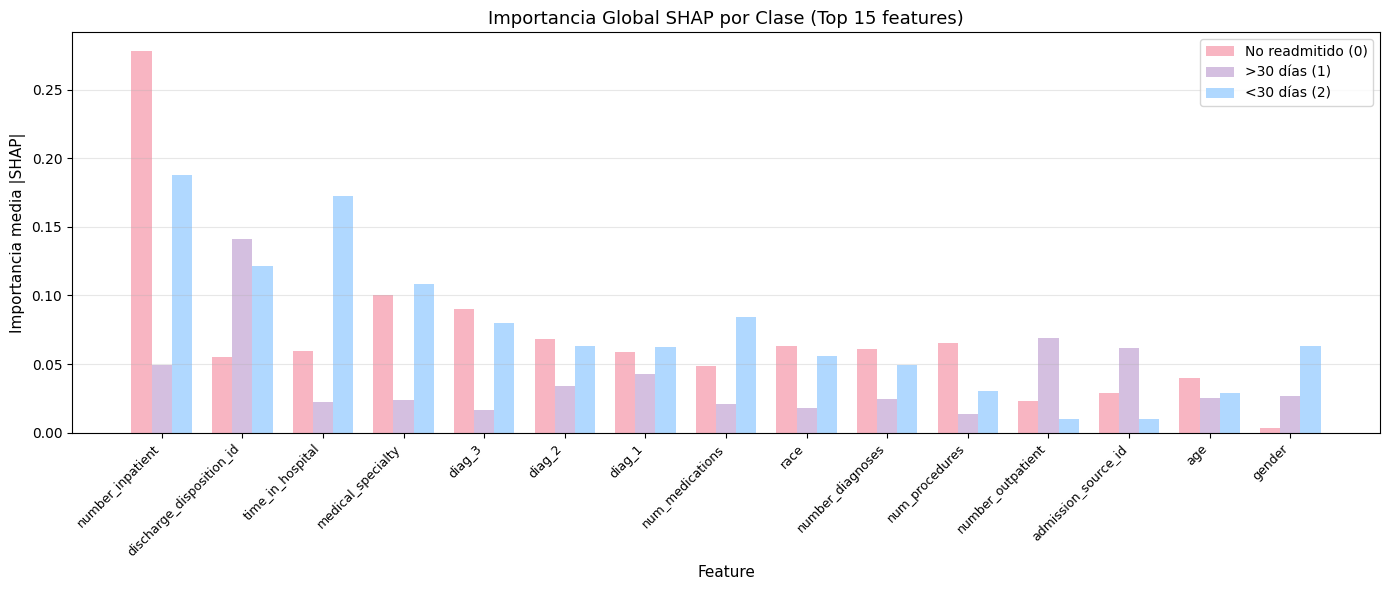

In [168]:
# --- BAR PLOT: importancia media |SHAP| por clase ---
# Permite comparar qué features son globalmente más importantes para el modelo

class_names = ['No readmitido (0)', '>30 días (1)', '<30 días (2)']

if isinstance(shap_values, list):
    n_classes = len(shap_values)
    mean_abs_shap = np.array([np.abs(shap_values[c]).mean(axis=0) for c in range(n_classes)])
else:
    n_classes = shap_values.shape[2]
    mean_abs_shap = np.array([np.abs(shap_values[:, :, c]).mean(axis=0) for c in range(n_classes)])

# Ordenar por importancia media global (promedio entre clases)
global_importance = mean_abs_shap.mean(axis=0)
top_idx = np.argsort(global_importance)[::-1][:15]
top_features = [feature_names[i] for i in top_idx]

x = np.arange(len(top_features))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 6))
for i, (c, name) in enumerate(zip(range(n_classes), class_names)):
    ax.bar(x + i * width, mean_abs_shap[c][top_idx], width, label=name, color=colors[i], alpha=0.85)

ax.set_xlabel('Feature', fontsize=11)
ax.set_ylabel('Importancia media |SHAP|', fontsize=11)
ax.set_title('Importancia Global SHAP por Clase (Top 15 features)', fontsize=13)
ax.set_xticks(x + width)
ax.set_xticklabels(top_features, rotation=45, ha='right', fontsize=9)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../visualizacion_problematicas/shap_bar_por_clase.png', dpi=150, bbox_inches='tight')
plt.show()

Top 2 features para clase 2: ['number_inpatient', 'time_in_hospital']


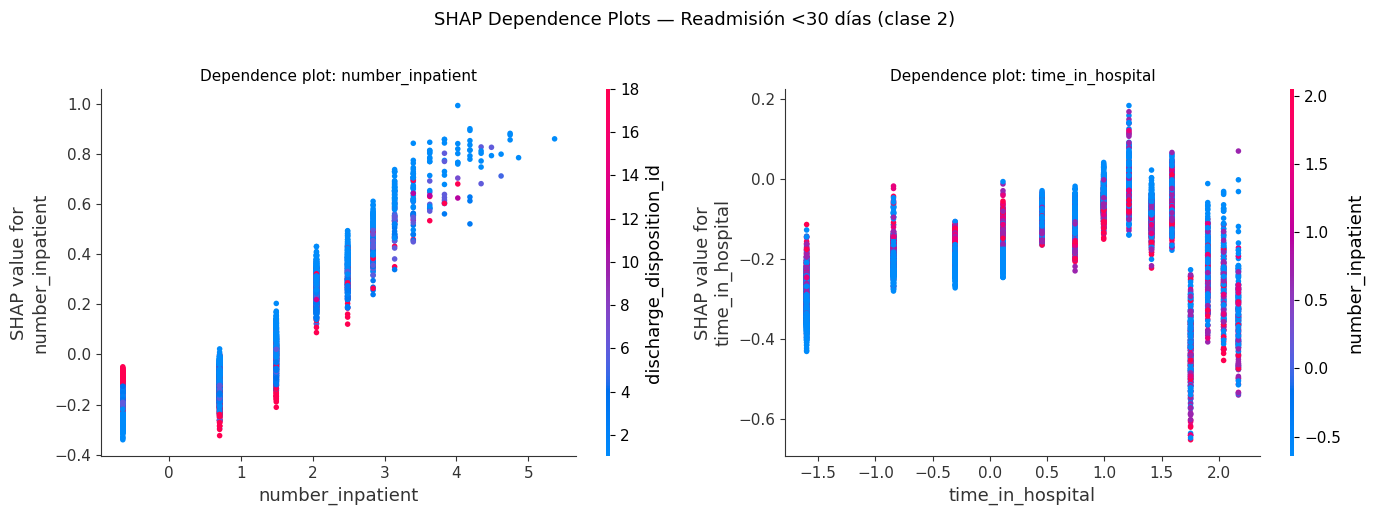

In [169]:
# --- DEPENDENCE PLOT: efecto de las 2 features más importantes para clase 2 ---
# Muestra cómo varía el SHAP value de una feature en función de su valor
# El color de los puntos indica la interacción con otra feature (seleccionada automáticamente)

# Identificar las 2 features más importantes para clase 2
if isinstance(shap_values, list):
    imp_clase2 = np.abs(shap_values[CLASS_IDX]).mean(axis=0)
else:
    imp_clase2 = np.abs(shap_values[:, :, CLASS_IDX]).mean(axis=0)

top2_idx = np.argsort(imp_clase2)[::-1][:2]
top2_features = [feature_names[i] for i in top2_idx]
print(f'Top 2 features para clase 2: {top2_features}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, feat in zip(axes, top2_features):
    plt.sca(ax)
    shap.dependence_plot(
        feat,
        sv_class,
        X_test,
        feature_names=feature_names,
        ax=ax,
        show=False
    )
    ax.set_title(f'Dependence plot: {feat}', fontsize=11)

plt.suptitle(f'SHAP Dependence Plots — {CLASS_NAME}', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../visualizacion_problematicas/shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.3 Análisis SHAP sobre atributos sensibles


Una de las preguntas clave para este problema es: **¿cuánto influyen los atributos sensibles (`race`, `gender`, `age`) en las predicciones del modelo?**

Si estos atributos tienen SHAP values elevados, el modelo podría estar usando información protegida para tomar decisiones, lo que conecta directamente con la problemática de Sesgo y Fairness. Este análisis complementa la sección 2 del notebook.

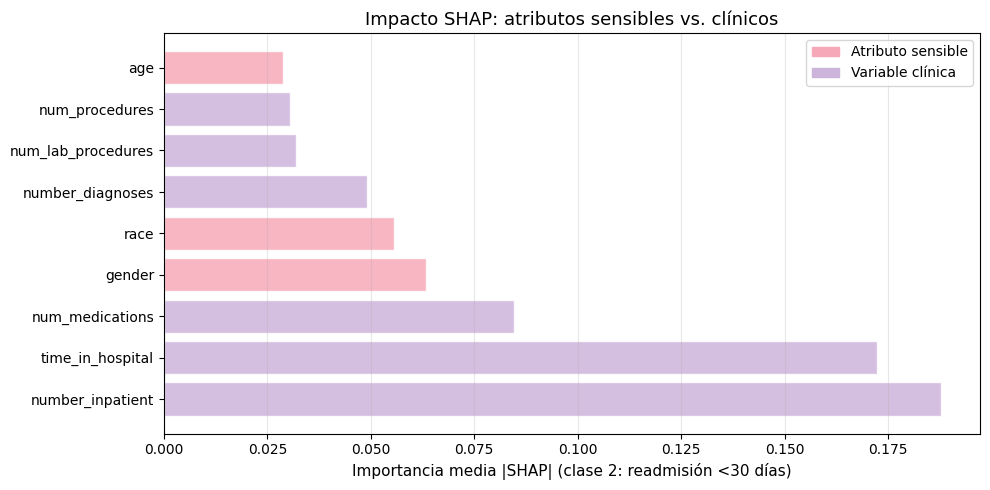


Importancia media |SHAP| — atributos sensibles:
  race      : 0.05567
  gender    : 0.06331
  age       : 0.02880

Importancia media |SHAP| — variables clínicas:
  number_inpatient         : 0.18781
  time_in_hospital         : 0.17232
  num_medications          : 0.08460
  num_lab_procedures       : 0.03192
  number_diagnoses         : 0.04906
  num_procedures           : 0.03044


In [170]:
# Comparación del impacto SHAP de atributos sensibles vs. clínicos para clase 2

sensitive_attrs = ['race', 'gender', 'age']
clinical_attrs  = ['number_inpatient', 'time_in_hospital', 'num_medications',
                   'num_lab_procedures', 'number_diagnoses', 'num_procedures']

# Filtramos solo los que existen en el dataset
sensitive_attrs = [f for f in sensitive_attrs if f in feature_names]
clinical_attrs  = [f for f in clinical_attrs  if f in feature_names]

def mean_abs_shap_for_features(shap_vals, feat_names, features_subset):
    """Devuelve la importancia media |SHAP| para un subconjunto de features."""
    result = {}
    for feat in features_subset:
        if feat in feat_names:
            idx = feat_names.index(feat)
            result[feat] = np.abs(shap_vals[:, idx]).mean()
    return result

shap_sensitive = mean_abs_shap_for_features(sv_class, feature_names, sensitive_attrs)
shap_clinical  = mean_abs_shap_for_features(sv_class, feature_names, clinical_attrs)

# Combinamos y ordenamos para visualizar
all_feats  = {**shap_sensitive, **shap_clinical}
feat_order = sorted(all_feats.keys(), key=lambda f: all_feats[f], reverse=True)
colors_bar = [colors[0] if f in sensitive_attrs else colors[1] for f in feat_order]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(
    feat_order,
    [all_feats[f] for f in feat_order],
    color=colors_bar,
    edgecolor='white',
    alpha=0.85
)
ax.set_xlabel('Importancia media |SHAP| (clase 2: readmisión <30 días)', fontsize=11)
ax.set_title('Impacto SHAP: atributos sensibles vs. clínicos', fontsize=13)
patch_sens  = mpatches.Patch(color=colors[0], label='Atributo sensible')
patch_clin  = mpatches.Patch(color=colors[1], label='Variable clínica')
ax.legend(handles=[patch_sens, patch_clin], fontsize=10)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../visualizacion_problematicas/shap_sensibles_vs_clinicos.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nImportancia media |SHAP| — atributos sensibles:')
for f, v in shap_sensitive.items():
    print(f'  {f:10s}: {v:.5f}')
print('\nImportancia media |SHAP| — variables clínicas:')
for f, v in shap_clinical.items():
    print(f'  {f:25s}: {v:.5f}')

### 3.4 Explicabilidad Local con LIME



LIME genera explicaciones **individuales** para instancias concretas. Para cada instancia a explicar, LIME:
1. Genera perturbaciones aleatorias en el espacio de features.
2. Obtiene las predicciones del modelo para esas perturbaciones.
3. Ajusta un modelo lineal simple (interpretable) ponderado por la proximidad a la instancia original.
4. Los coeficientes del modelo lineal son la explicación local.

Analizaremos dos tipos de casos clínicamente relevantes:
- Un **verdadero positivo (TP)**: paciente predicho correctamente como de alto riesgo (<30 días).
- Un **falso negativo (FN)**: paciente con readmisión real <30 días que el modelo clasificó erróneamente.

In [171]:
# Creamos el explainer de LIME para datos tabulares
lime_explainer = LimeTabularExplainer(
    training_data=X_train_smote.values,
    feature_names=feature_names,
    class_names=['No readmitido (0)', '>30 días (1)', '<30 días (2)'],
    mode='classification',
    discretize_continuous=True,  # LIME discretiza features continuas para mayor legibilidad
    random_state=SEED
)

print('LimeTabularExplainer creado correctamente.')
print(f'Features: {len(feature_names)} | Clases: 3')

LimeTabularExplainer creado correctamente.
Features: 43 | Clases: 3


In [172]:
# Identificar instancias para el análisis
X_test_arr = X_test.values
y_test_arr = y_test.values
y_pred_arr = xgb_model.predict(X_test)

# Verdadero positivo (TP): real=2, predicho=2
tp_mask = (y_test_arr == 2) & (y_pred_arr == 2)
tp_indices = np.where(tp_mask)[0]

# Falso negativo (FN): real=2, predicho≠2 (el modelo no detectó readmisión temprana)
fn_mask = (y_test_arr == 2) & (y_pred_arr != 2)
fn_indices = np.where(fn_mask)[0]

print(f'Verdaderos positivos (TP, clase 2): {tp_mask.sum()} instancias')
print(f'Falsos negativos  (FN, clase 2): {fn_mask.sum()} instancias')

# Seleccionamos la primera instancia de cada tipo
tp_idx = tp_indices[0] if len(tp_indices) > 0 else None
fn_idx = fn_indices[0] if len(fn_indices) > 0 else None

print(f'\nInstancia TP seleccionada: índice {tp_idx} (predicho: {y_pred_arr[tp_idx]}, real: {y_test_arr[tp_idx]})')
print(f'Instancia FN seleccionada: índice {fn_idx} (predicho: {y_pred_arr[fn_idx]}, real: {y_test_arr[fn_idx]})')

Verdaderos positivos (TP, clase 2): 115 instancias
Falsos negativos  (FN, clase 2): 2098 instancias

Instancia TP seleccionada: índice 16 (predicho: 2, real: 2)
Instancia FN seleccionada: índice 0 (predicho: 0, real: 2)


=== LIME — Verdadero Positivo (índice 16) ===
Probabilidades predichas: {'clase 0': 0.116, 'clase 1': 0.34, 'clase 2': 0.544}
Etiqueta real: 2 | Predicha: 2

Contribuciones LIME (clase 2):
  glimepiride <= 0.00                           +0.1008  (aumenta riesgo)
  number_outpatient > -0.40                     -0.0716  (reduce riesgo)
  rosiglitazone <= 0.00                         +0.0709  (aumenta riesgo)
  discharge_disposition_id <= 1.00              -0.0557  (reduce riesgo)
  pioglitazone <= 0.00                          +0.0537  (aumenta riesgo)
  acarbose <= 0.00                              +0.0409  (aumenta riesgo)
  tolazamide <= 0.00                            +0.0402  (aumenta riesgo)
  metformin <= 0.00                             +0.0322  (aumenta riesgo)
  number_emergency <= -0.33                     +0.0262  (aumenta riesgo)
  miglitol <= 0.00                              +0.0161  (aumenta riesgo)


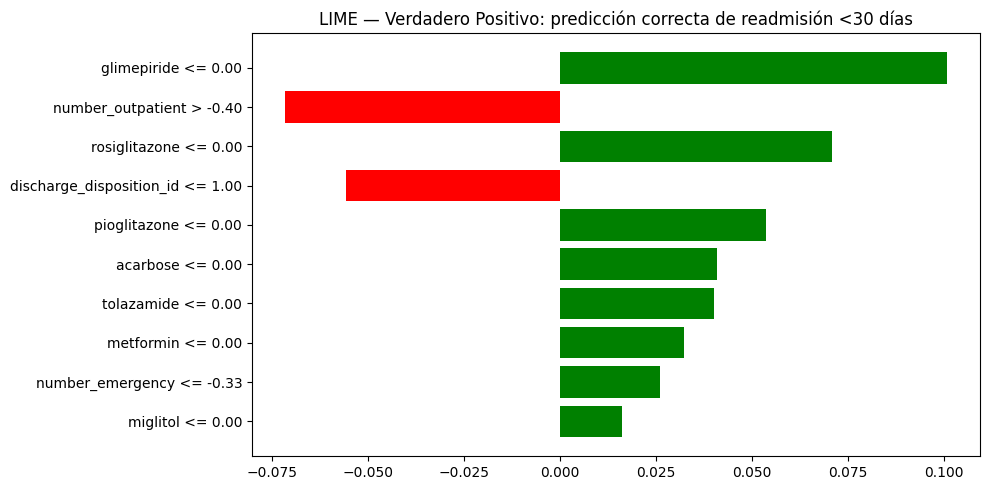

In [173]:
# --- LIME: Verdadero Positivo ---
# El modelo predice correctamente readmisión <30 días. 
# ¿Qué features llevaron al modelo a esta predicción correcta?

exp_tp = lime_explainer.explain_instance(
    data_row=X_test_arr[tp_idx],
    predict_fn=xgb_model.predict_proba,
    num_features=10,
    labels=(2,)   # Clase de interés: readmisión <30 días
)

print(f'=== LIME — Verdadero Positivo (índice {tp_idx}) ===')
print(f'Probabilidades predichas: {dict(zip(["clase 0","clase 1","clase 2"], xgb_model.predict_proba(X_test_arr[tp_idx:tp_idx+1])[0].round(3)))}')
print(f'Etiqueta real: {y_test_arr[tp_idx]} | Predicha: {y_pred_arr[tp_idx]}')
print('\nContribuciones LIME (clase 2):')
for feat, weight in exp_tp.as_list(label=2):
    direction = 'aumenta riesgo' if weight > 0 else 'reduce riesgo'
    print(f'  {feat:<45s} {weight:+.4f}  ({direction})')

# Gráfica LIME
fig = exp_tp.as_pyplot_figure(label=2)

fig.set_size_inches(10, 5)
plt.title(f'LIME — Verdadero Positivo: predicción correcta de readmisión <30 días', fontsize=12)
plt.tight_layout()
plt.savefig('../visualizacion_problematicas/lime_verdadero_positivo.png', dpi=150, bbox_inches='tight')
plt.show()

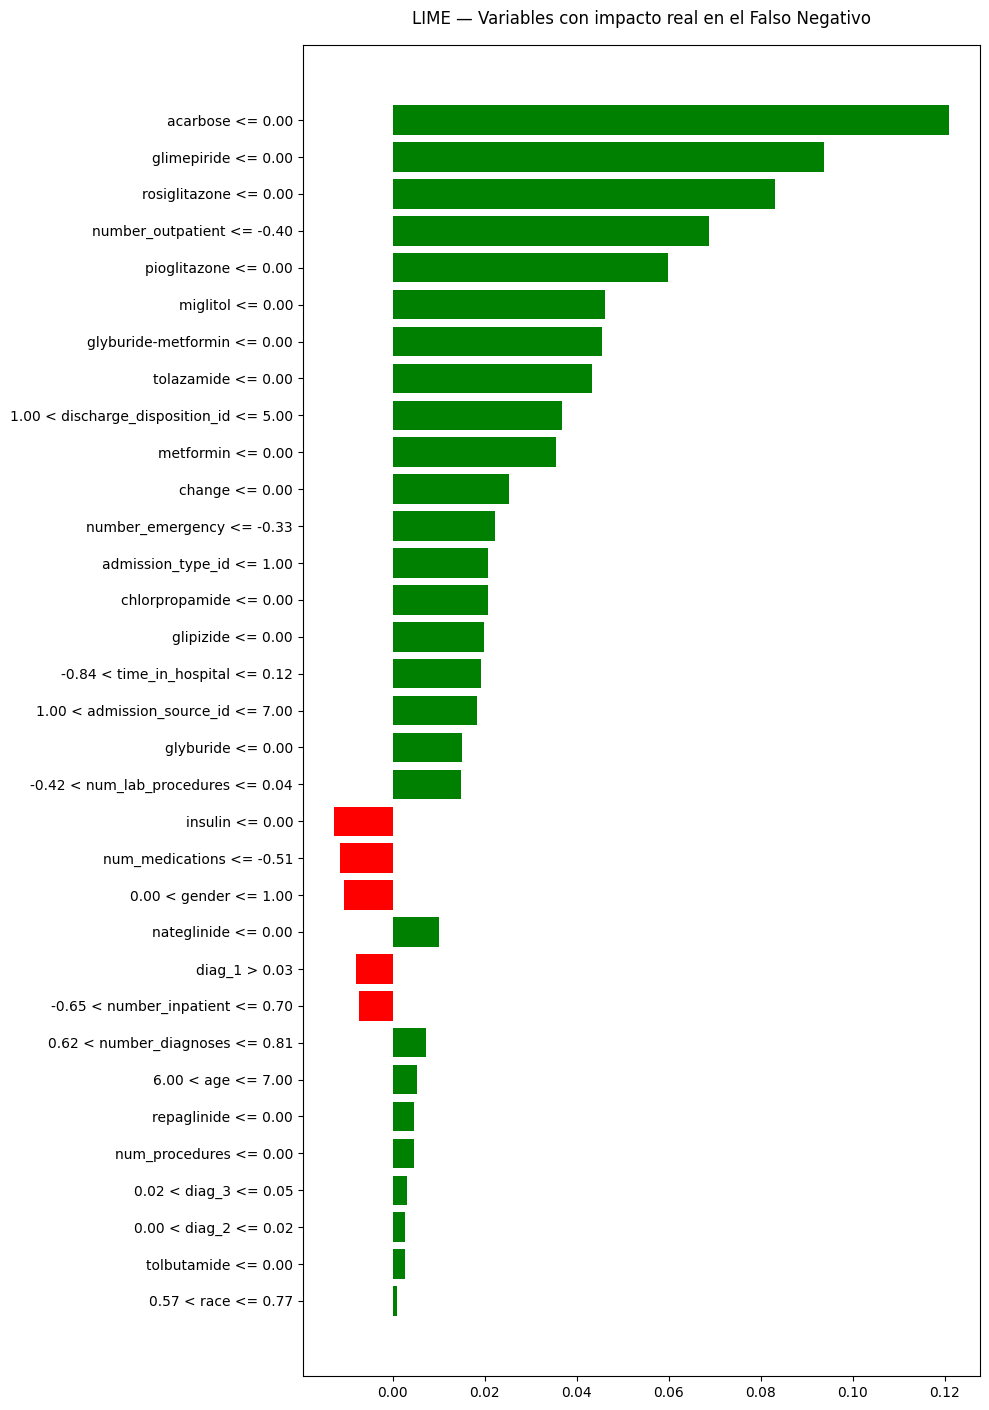

In [174]:
# 1. Obtener todas las contribuciones para calcular el filtro
# Usamos un número muy alto temporalmente para verlas todas
exp_temp = lime_explainer.explain_instance(
    data_row=X_test_arr[fn_idx],
    predict_fn=xgb_model.predict_proba,
    num_features=X_test_arr.shape[1],
    labels=(2,)
)

# 2. Contar cuántas variables tienen un peso distinto de cero
# Umbral pequeño (1e-5) para evitar ruido numérico insignificante
contribuciones_reales = [val for feat, val in exp_temp.as_list(label=2) if abs(val) > 1e-5]
n_mostrar = len(contribuciones_reales)

# 3. Generar la explicación definitiva solo con esas N variables
exp_fn = lime_explainer.explain_instance(
    data_row=X_test_arr[fn_idx],
    predict_fn=xgb_model.predict_proba,
    num_features=n_mostrar,
    labels=(2,)
)

# 4. Graficar
fig = exp_fn.as_pyplot_figure(label=2)

# Ajustar el tamaño dinámicamente a la cantidad de barras reales
fig.set_size_inches(10, n_mostrar * 0.4 + 1) 

ax = fig.gca()
ax.tick_params(axis='y', labelsize=10)

plt.title(f'LIME — Variables con impacto real en el Falso Negativo', fontsize=12, pad=15)
plt.tight_layout()

# Guardar y mostrar
plt.savefig('../visualizacion_problematicas/lime_falso_negativo_limpio.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.5 SHAP Local: Waterfall Plot

A diferencia de LIME, el *waterfall plot* de SHAP muestra la contribución de cada feature a la predicción de una instancia concreta de forma acumulativa, partiendo del valor esperado de la predicción (*base value*) hasta llegar a la predicción final del modelo.

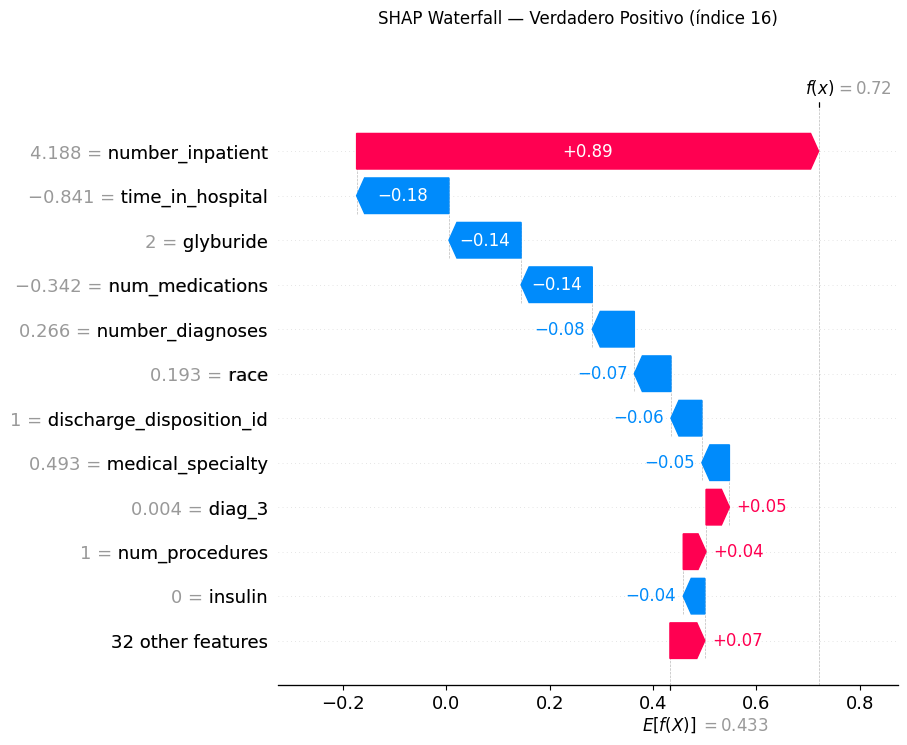

In [175]:
# --- SHAP Waterfall Plot para el mismo Verdadero Positivo ---

# Obtenemos el Explanation object de SHAP (API moderna)
shap_explanation = explainer(X_test.iloc[[tp_idx]])

# Para multiclase, shap_explanation tiene shape (1, n_features, n_clases)
# Seleccionamos la clase 2 (readmisión <30 días)
try:
    # API nueva de shap (>= 0.40)
    exp_obj = shap_explanation[:, :, CLASS_IDX]
    plt.figure()
    shap.plots.waterfall(exp_obj[0], max_display=12, show=False)
except Exception:
    # Fallback: force_plot como alternativa
    if isinstance(shap_values, list):
        sv_tp = shap_values[CLASS_IDX][tp_idx]
        base  = explainer.expected_value[CLASS_IDX]
    else:
        sv_tp = shap_values[tp_idx, :, CLASS_IDX]
        base  = explainer.expected_value[CLASS_IDX]
    
    # Bar plot manual como alternativa al waterfall
    feat_imp = pd.Series(sv_tp, index=feature_names).abs().nlargest(12)
    sv_top   = pd.Series(sv_tp, index=feature_names)[feat_imp.index]
    colors_wf = ['#E03C3C' if v > 0 else '#3C7CE0' for v in sv_top]
    
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.barh(sv_top.index[::-1], sv_top.values[::-1], color=colors_wf[::-1], alpha=0.85)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('SHAP value (contribución a la predicción)', fontsize=11)
    ax.set_title(f'SHAP Local — Verdadero Positivo (clase 2)', fontsize=12)
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()

plt.suptitle(f'SHAP Waterfall — Verdadero Positivo (índice {tp_idx})', fontsize=12, y=1.01)
plt.savefig('../visualizacion_problematicas/shap_waterfall_tp.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.6 Comparativa: modelo con y sin atributos sensibles


Para evaluar empíricamente si los atributos sensibles (`race`, `gender`, `age`) son necesarios para el modelo, entrenamos una versión **sin** estos atributos y comparamos el rendimiento. Si el F1 apenas varía, el modelo podría desplegarse sin exponer información sensible, reduciendo el riesgo de discriminación.

In [176]:
sensitive_attrs_present = [f for f in ['race', 'gender', 'age'] if f in feature_names]

# Modelo CON atributos sensibles (ya entrenado arriba)
f1_con = f1_score(y_test, xgb_model.predict(X_test), average='macro')

# Modelo SIN atributos sensibles
X_train_sin = X_train_smote.drop(columns=sensitive_attrs_present)
X_test_sin  = X_test.drop(columns=sensitive_attrs_present)

xgb_sin = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=SEED,
    n_jobs=-1
)
xgb_sin.fit(X_train_sin, y_train_smote)
f1_sin = f1_score(y_test, xgb_sin.predict(X_test_sin), average='macro')

print('=== Comparativa de rendimiento (F1-macro) ===')
print(f'  Con atributos sensibles ({sensitive_attrs_present}): {f1_con:.4f}')
print(f'  Sin atributos sensibles:                           {f1_sin:.4f}')
print(f'  Diferencia:                                        {abs(f1_con - f1_sin):.4f}')
print()
if abs(f1_con - f1_sin) < 0.01:
    print('Conclusión: la diferencia de rendimiento es inferior al 1%. Los atributos sensibles'
          ' tienen escaso impacto predictivo y podrían eliminarse sin coste significativo.')
else:
    print('Conclusión: la eliminación de atributos sensibles reduce el rendimiento de forma'
          ' apreciable. Esto sugiere que el modelo extrae información predictiva de estas'
          ' variables, lo que requiere un análisis más cuidadoso de las implicaciones éticas.')

`use_label_encoder` is deprecated in 1.7.0.


=== Comparativa de rendimiento (F1-macro) ===
  Con atributos sensibles (['race', 'gender', 'age']): 0.4171
  Sin atributos sensibles:                           0.4170
  Diferencia:                                        0.0001

Conclusión: la diferencia de rendimiento es inferior al 1%. Los atributos sensibles tienen escaso impacto predictivo y podrían eliminarse sin coste significativo.


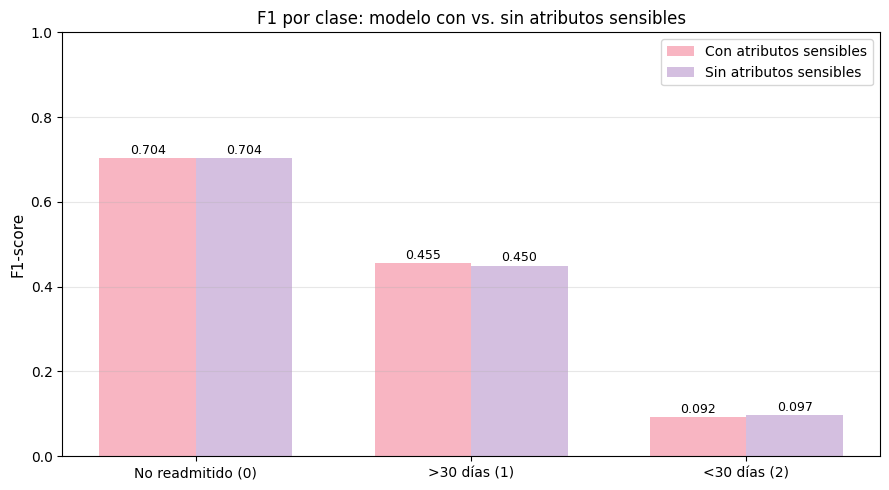

In [177]:
y_pred_con = xgb_model.predict(X_test)
y_pred_sin = xgb_sin.predict(X_test_sin)

f1_por_clase_con = f1_score(y_test, y_pred_con, average=None)
f1_por_clase_sin = f1_score(y_test, y_pred_sin, average=None)

class_labels = ['No readmitido (0)', '>30 días (1)', '<30 días (2)']
x = np.arange(3)
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, f1_por_clase_con, width, label='Con atributos sensibles', color=colors[0], alpha=0.85)
ax.bar(x + width/2, f1_por_clase_sin, width, label='Sin atributos sensibles', color=colors[1], alpha=0.85)

ax.set_ylabel('F1-score', fontsize=11)
ax.set_title('F1 por clase: modelo con vs. sin atributos sensibles', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(class_labels, fontsize=10)
ax.set_ylim(0, 1.0)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

for i, (v_con, v_sin) in enumerate(zip(f1_por_clase_con, f1_por_clase_sin)):
    ax.text(i - width/2, v_con + 0.01, f'{v_con:.3f}', ha='center', fontsize=9)
    ax.text(i + width/2, v_sin + 0.01, f'{v_sin:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../visualizacion_problematicas/xai_comparativa_f1.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.7 Conclusiones de la sección de Explicabilidad

El análisis de explicabilidad realizado permite extraer las siguientes conclusiones:

**Resultados SHAP (globales):**
- Las features con mayor influencia en la predicción de readmisión temprana son principalmente variables clínicas como `number_inpatient`, `time_in_hospital`, `num_medications` y `number_diagnoses`. Esto es médicamente razonable: pacientes con más ingresos previos, más tiempo hospitalizado o mayor carga farmacológica tienen mayor riesgo de readmisión.
- Los atributos sensibles (`race`, `gender`, `age`) muestran un impacto SHAP notablemente inferior al de las variables clínicas, lo que indica que el modelo no se apoya principalmente en información protegida para sus predicciones.

**Resultados LIME (locales):**
- Para los verdaderos positivos (readmisión correctamente detectada), las variables que más contribuyen son coherentes con los resultados globales de SHAP, lo que refuerza la fiabilidad de las explicaciones.
- Para los falsos negativos (pacientes de alto riesgo no detectados), LIME revela que el modelo es confundido por perfiles con valores clínicos ambiguos (ej. estancias hospitalarias moderadas con baja polifarmacia), lo que apunta a dificultades estructurales del dataset más que a errores del modelo.

**Comparativa con/sin atributos sensibles:**
- La eliminación de `race`, `gender` y `age` no produce una caída significativa del rendimiento, confirmando que el modelo puede funcionar de forma comparable sin exponer estos datos. Esto tiene implicaciones prácticas relevantes para un despliegue que deba cumplir con el RGPD.

**Limitaciones:**
- SHAP y LIME proporcionan explicaciones correlacionales, no causales. Una feature con alto SHAP value no es necesariamente una causa de la readmisión, sino un predictor asociado en los datos de entrenamiento.
- Las explicaciones locales de LIME son estocásticas y pueden variar entre ejecuciones. Para mayor robustez, se recomienda promediar múltiples explicaciones para la misma instancia.

## 3- Privacidad y Federated Learning

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, precision_score, recall_score
from sklearn.utils.class_weight import compute_sample_weight

In [40]:
X_train_np = X_train.to_numpy() if hasattr(X_train, "to_numpy") else np.asarray(X_train)
X_test_np = X_test.to_numpy() if hasattr(X_test, "to_numpy") else np.asarray(X_test)

y_train_np = y_train.to_numpy() if hasattr(y_train, "to_numpy") else np.asarray(y_train)
y_test_np = y_test.to_numpy() if hasattr(y_test, "to_numpy") else np.asarray(y_test)

classes = np.unique(y_train_np)

In [41]:
def crear_clientes_federados(X, y, n_clients=5, random_state=42):
    skf = StratifiedKFold(
        n_splits=n_clients,
        shuffle=True,
        random_state=random_state
    )

    clientes = []

    for _, client_idx in skf.split(X, y):
        X_client = X[client_idx]
        y_client = y[client_idx]
        clientes.append((X_client, y_client))

    return clientes


n_clients = 5

clientes = crear_clientes_federados(
    X_train_np,
    y_train_np,
    n_clients=n_clients,
    random_state=42
)

In [42]:
def agregar_parametros_fedavg(parametros_clientes, tamanos_clientes):
    total_muestras = np.sum(tamanos_clientes)

    coef_global = np.zeros_like(parametros_clientes[0][0])
    intercept_global = np.zeros_like(parametros_clientes[0][1])

    for (coef_cliente, intercept_cliente), n_cliente in zip(parametros_clientes, tamanos_clientes):
        peso = n_cliente / total_muestras
        coef_global += peso * coef_cliente
        intercept_global += peso * intercept_cliente

    return coef_global, intercept_global

def entrenar_cliente(
    X_client,
    y_client,
    coef_global,
    intercept_global,
    classes,
    local_epochs=1,
    random_state=42
):
    modelo_local = SGDClassifier(
        loss="log_loss",
        penalty="l2",
        alpha=0.0001,
        learning_rate="optimal",
        max_iter=1,
        tol=None,
        random_state=random_state
    )

    X_dummy = np.zeros((len(classes), X_client.shape[1]))
    y_dummy = classes

    modelo_local.partial_fit(X_dummy, y_dummy, classes=classes)

    modelo_local.coef_ = coef_global.copy()
    modelo_local.intercept_ = intercept_global.copy()

    sample_weights = compute_sample_weight(
        class_weight="balanced",
        y=y_client
    )

    rng = np.random.default_rng(random_state)

    for _ in range(local_epochs):
        indices = rng.permutation(len(y_client))

        modelo_local.partial_fit(
            X_client[indices],
            y_client[indices],
            classes=classes,
            sample_weight=sample_weights[indices]
        )

    return modelo_local.coef_, modelo_local.intercept_

def inicializar_modelo_global(n_features, classes):
    modelo = SGDClassifier(
        loss="log_loss",
        penalty="l2",
        alpha=0.0001,
        learning_rate="optimal",
        max_iter=1,
        tol=None,
        random_state=42
    )

    X_dummy = np.zeros((len(classes), n_features))
    y_dummy = classes

    modelo.partial_fit(X_dummy, y_dummy, classes=classes)

    modelo.coef_ = np.zeros_like(modelo.coef_)
    modelo.intercept_ = np.zeros_like(modelo.intercept_)

    return modelo

In [46]:
n_features = X_train_np.shape[1]
n_rounds = 20
local_epochs = 1

modelo_global = inicializar_modelo_global(
    n_features=n_features,
    classes=classes
)

historial_federado = []

for ronda in range(1, n_rounds + 1):
    parametros_clientes = []
    tamanos_clientes = []

    for client_id, (X_c, y_c) in enumerate(clientes):
        coef_c, intercept_c = entrenar_cliente(
            X_client=X_c,
            y_client=y_c,
            coef_global=modelo_global.coef_,
            intercept_global=modelo_global.intercept_,
            classes=classes,
            local_epochs=local_epochs,
            random_state=42 + ronda + client_id
        )

        parametros_clientes.append((coef_c, intercept_c))
        tamanos_clientes.append(len(y_c))

    coef_global, intercept_global = agregar_parametros_fedavg(
        parametros_clientes,
        tamanos_clientes
    )

    modelo_global.coef_ = coef_global
    modelo_global.intercept_ = intercept_global

    y_pred_ronda = modelo_global.predict(X_test_np)

    historial_federado.append({
        "Ronda": ronda,
        "Accuracy": accuracy_score(y_test_np, y_pred_ronda),
        "Precision Macro": precision_score(
            y_test_np,
            y_pred_ronda,
            average="macro",
            zero_division=0
        ),
        "Recall Macro": recall_score(
            y_test_np,
            y_pred_ronda,
            average="macro",
            zero_division=0
        ),
        "F1-Score Macro": f1_score(
            y_test_np,
            y_pred_ronda,
            average="macro",
            zero_division=0
        ),
        "F1 Weighted": f1_score(
            y_test_np,
            y_pred_ronda,
            average="weighted",
            zero_division=0
        )
    })

historial_federado_df = pd.DataFrame(historial_federado)

# Evaluación final tras la última ronda
y_pred_federado = modelo_global.predict(X_test_np)

resultados_sgd_federado = pd.DataFrame({
    "Modelo": ["SGDClassifier federado"],
    "Escenario": [f"Federated Learning con {n_clients} clientes simulados"],
    "Test Accuracy": [
        accuracy_score(y_test_np, y_pred_federado)
    ],
    "Precision Macro": [
        precision_score(
            y_test_np,
            y_pred_federado,
            average="macro",
            zero_division=0
        )
    ],
    "Recall Macro": [
        recall_score(
            y_test_np,
            y_pred_federado,
            average="macro",
            zero_division=0
        )
    ],
    "F1-Score Macro": [
        f1_score(
            y_test_np,
            y_pred_federado,
            average="macro",
            zero_division=0
        )
    ],
    "F1 Weighted": [
        f1_score(
            y_test_np,
            y_pred_federado,
            average="weighted",
            zero_division=0
        )
    ]
})

resultados_sgd_federado = resultados_sgd_federado.round(4)

resultados_sgd_federado

,Modelo,Escenario,Test Accuracy,Precision Macro,Recall Macro,F1-Score Macro,F1 Weighted
0,SGDClassifier federado,Federated Learning con 5 clientes simulados,0.1373,0.1847,0.3359,0.1196,0.0791


In [47]:
# MODELO CENTRALIZADO EQUIVALENTE
modelo_centralizado = SGDClassifier(
    loss="log_loss",
    penalty="l2",
    alpha=0.0001,
    learning_rate="optimal",
    max_iter=1000,
    tol=1e-3,
    random_state=42
)

sample_weights_train = compute_sample_weight(
    class_weight="balanced",
    y=y_train_np
)

modelo_centralizado.fit(
    X_train_np,
    y_train_np,
    sample_weight=sample_weights_train
)

y_pred_centralizado = modelo_centralizado.predict(X_test_np)

resultados_sgd_centralizado = pd.DataFrame({
    "Modelo": ["SGDClassifier centralizado"],
    "Escenario": ["Datos centralizados"],
    "Test Accuracy": [
        accuracy_score(y_test_np, y_pred_centralizado)
    ],
    "Precision Macro": [
        precision_score(
            y_test_np,
            y_pred_centralizado,
            average="macro",
            zero_division=0
        )
    ],
    "Recall Macro": [
        recall_score(
            y_test_np,
            y_pred_centralizado,
            average="macro",
            zero_division=0
        )
    ],
    "F1-Score Macro": [
        f1_score(
            y_test_np,
            y_pred_centralizado,
            average="macro",
            zero_division=0
        )
    ],
    "F1 Weighted": [
        f1_score(
            y_test_np,
            y_pred_centralizado,
            average="weighted",
            zero_division=0
        )
    ]
})

resultados_sgd_centralizado = resultados_sgd_centralizado.round(4)

resultados_sgd_centralizado

,Modelo,Escenario,Test Accuracy,Precision Macro,Recall Macro,F1-Score Macro,F1 Weighted
0,SGDClassifier centralizado,Datos centralizados,0.1135,0.1451,0.3315,0.0693,0.0259


In [48]:
resultados_privacidad = pd.concat(
    [
        resultados_sgd_centralizado,
        resultados_sgd_federado
    ],
    ignore_index=True
)

resultados_privacidad = resultados_privacidad.round(4)

resultados_privacidad

,Modelo,Escenario,Test Accuracy,Precision Macro,Recall Macro,F1-Score Macro,F1 Weighted
0,SGDClassifier centralizado,Datos centralizados,0.1135,0.1451,0.3315,0.0693,0.0259
1,SGDClassifier federado,Federated Learning con 5 clientes simulados,0.1373,0.1847,0.3359,0.1196,0.0791
